### Purpose: Get a visual for the 10 UTC event
Need to do:
1. figure out a good bounding box
2. figure out why YKNF looks bigger than FSMI projection?
3. change red channel to green channel bc focusing on picket fences 

### Imports

In [26]:
import altitude_helper
import skymap_data_helper

import importlib
importlib.reload(altitude_helper)
from altitude_helper import *

# for interpolation
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image
from scipy.stats import pearsonr # correlation

import os # folder stuff 

import threading
import time 

from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from functools import partial
from tqdm.notebook import tqdm # since in jupyter

from matplotlib.path import Path # for polygon bounding box 

### Loading Data

In [2]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 10 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


/home/molidae/Desktop/berkeley/ssl/skymap_data_helper.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["valid_end"] = df["valid_end"].fillna(pd.to_datetime(datetime.utcnow().date()))  # today at midnight UTC


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


### Sample Run
- to pick out the best frame / timestamp

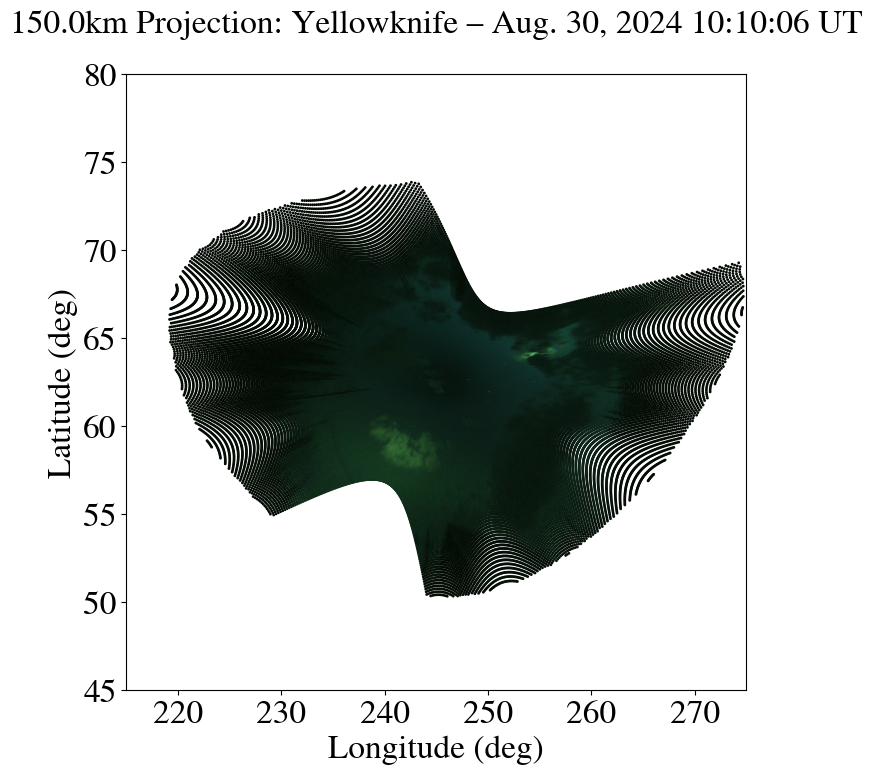

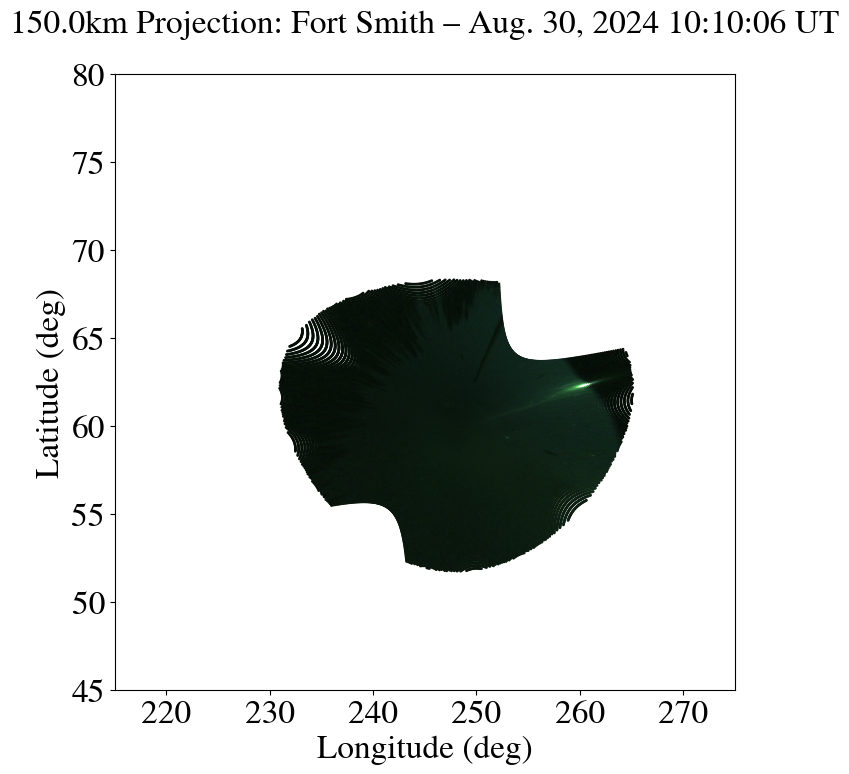

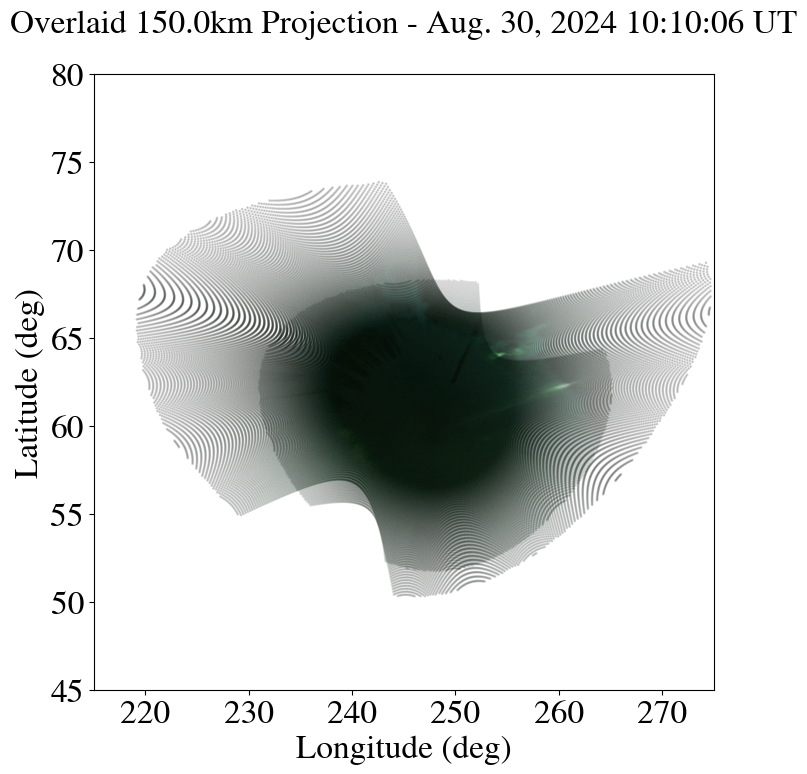

In [30]:
h_target_arr = [150000] #[100000, 110000, 120000, 130000, 140000, 150000, 160000, 170000, 180000, 190000, 200000, 210000, 220000, 230000, 240000, 250000, 260000, 270000, 280000, 290000, 300000]
# time_index = [0,1199] = 10:00 - 10:59:57
# each time_index = 1 is 3 seconds (interval at which images taken)
# each time_index = 200 is 10 minutes
time_index = 202
site_name_yknf = "Yellowknife"
site_name_fsmi = "Fort Smith"


for h_target in h_target_arr:
    #----- YKNF ------ #
    lat_cam_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
    lon_cam_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
    full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
    full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]
    
    
    yknf_lat_proj_arr, yknf_lon_proj_arr = new_spherical_project_lat_lon(full_azimuth_yknf, 
                                                                         full_elevation_yknf,
                                                                         lat_cam_yknf,
                                                                         lon_cam_yknf,
                                                                         h_target,
                                                                        )
    
    #----- FSMI ------ #
    lat_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
    lon_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
    full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
    full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]
    
    fsmi_lat_proj_arr, fsmi_lon_proj_arr = spherical_project_lat_lon(full_azimuth_fsmi, 
                                                                     full_elevation_fsmi,
                                                                     lat_cam_fsmi,
                                                                     lon_cam_fsmi,
                                                                     h_target,
                                                                    )

    green_plot_lat_lon(yknf_rgb_asi_ds, fsmi_rgb_asi_ds, time_index, site_name_yknf, site_name_fsmi, 
                 yknf_lat_proj_arr, yknf_lon_proj_arr, fsmi_lat_proj_arr, fsmi_lon_proj_arr, h_target)
    


### Setup for Multithreading (to get plot)

In [ ]:
# needed yknf and fsmi arrs: lat, long, elevation, azimuth, yknf110 & fsmi110 mask to restrict plots
lat_cam_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_cam_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

lat_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]

og_h = 150000
new_h = 200000
time_index = 202
yknf_lat_proj, yknf_lon_proj = new_spherical_project_lat_lon(full_azimuth_yknf, full_elevation_yknf, lat_cam_yknf, lon_cam_yknf, new_h)
fsmi_lat_proj, fsmi_lon_proj = new_spherical_project_lat_lon(full_azimuth_fsmi, full_elevation_fsmi, lat_cam_fsmi, lon_cam_fsmi, new_h)

rgb_yknf, rgb_fsmi = mod_plot_lat_lon(yknf_rgb_asi_ds, fsmi_rgb_asi_ds, time_index, "Yellowknife", "Fort Smith", yknf_lat_proj, yknf_lon_proj, fsmi_lat_proj, fsmi_lon_proj, new_h)

# limiting interpolation locations (common region between fort smith and yknf
lat_min = min(np.nanmin(yknf_lat_proj), np.nanmin(fsmi_lat_proj))
lon_min = min(np.nanmin(yknf_lon_proj), np.nanmin(fsmi_lon_proj))
lat_max = max(np.nanmax(yknf_lat_proj), np.nanmax(fsmi_lat_proj))
lon_max = max(np.nanmax(yknf_lon_proj), np.nanmax(fsmi_lon_proj))

# common bounding box between yknf and fsmi (based on 150km projection) --> this is primarily for YKNF, hmmm
lat_min_box = 60.5
lat_max_box = 66
lon_min_box = 54
lon_max_box = 60

# reference longitude grid to use for the rest of the altitude projections
H_REF = 150000
_, yknf_lon_ref = new_spherical_project_lat_lon(
    full_azimuth_yknf, full_elevation_yknf,
    lat_cam_yknf, lon_cam_yknf,
    H_REF
)

_, fsmi_lon_ref = new_spherical_project_lat_lon(
    full_azimuth_fsmi, full_elevation_fsmi,
    lat_cam_fsmi, lon_cam_fsmi,
    H_REF
)

lon_step = 1.0  # degrees

GLOBAL_LON_MIN = int(np.floor(
    min(np.nanmin(yknf_lon_ref), np.nanmin(fsmi_lon_ref))
))

GLOBAL_LON_MAX = int(np.ceil(
    max(np.nanmax(yknf_lon_ref), np.nanmax(fsmi_lon_ref))
))

# array of longitudes to to slice at and get the max intensity 
GLOBAL_LON_ARR = np.arange( 
    GLOBAL_LON_MIN,
    GLOBAL_LON_MAX + lon_step,
    lon_step
)

# looping through different times and altitudes 
h_arr = [150000, 160000]#, 170000]#, 180000, 190000, 200000, 210000, 220000, 230000, 240000, 250000, 260000, 270000, 280000, 290000, 300000]
t_arr = [180]#, 190, 200, 210, 220, 230]#, 240, 250, 260, 270] # 100 --> 270
